### EDA: Overall Distribution, Delay by Train/Station

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

In [12]:
load_dotenv()
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}"
    f"@{os.getenv('MYSQL_HOST')}/{os.getenv('MYSQL_DATABASE')}"
)
 
os.makedirs("figures", exist_ok=True)

### Delay by Minutes

In [13]:
summary_query = """
SELECT
    COUNT(*) AS n_records,
    AVG(delay_minutes) AS mean_delay,
    STDDEV(delay_minutes) AS std_delay,
    MIN(delay_minutes) AS min_delay,
    MAX(delay_minutes) AS max_delay
FROM delays
"""
summary = pd.read_sql(text(summary_query), engine)
print(summary)

   n_records  mean_delay  std_delay  min_delay  max_delay
0     262256    38.35507  50.002883      -88.0     2774.0


#### Median in Pandas (As MySQL doesn't have a built in MEDIAN aggregate)

In [14]:
delay_series = pd.read_sql(text("SELECT delay_minutes FROM delays;"), engine)["delay_minutes"]
print("Median delay:", delay_series.median())

Median delay: 25.0


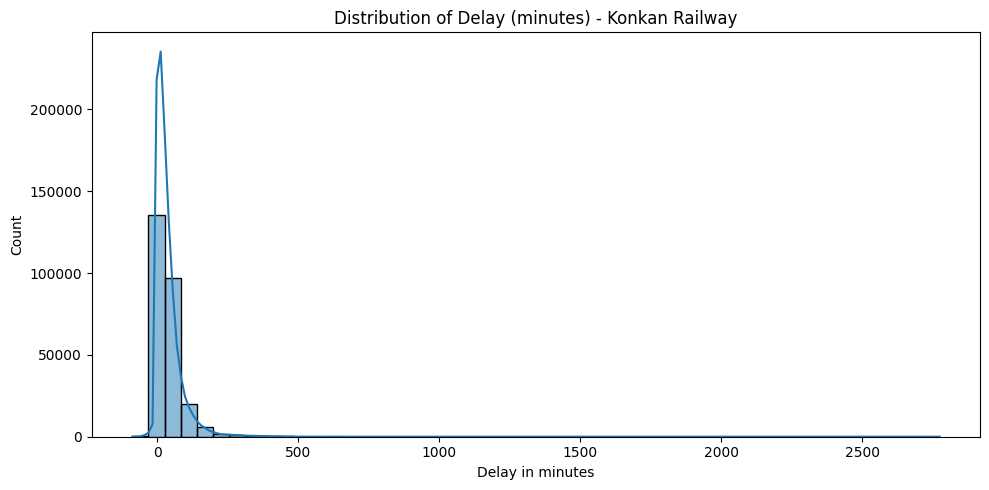

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(delay_series, bins=50, kde=True)
plt.title("Distribution of Delay (minutes) - Konkan Railway")
plt.xlabel("Delay in minutes")
plt.tight_layout()
plt.savefig("figures/delay_histogram.png")
plt.show()

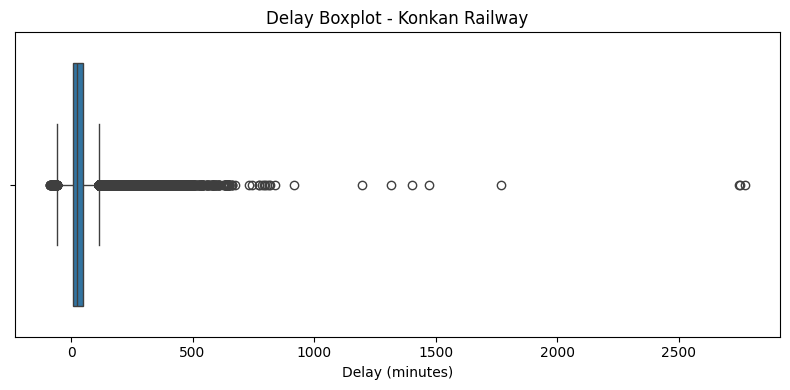

In [19]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=delay_series)
plt.title("Delay Boxplot - Konkan Railway")
plt.xlabel("Delay (minutes)")
plt.tight_layout()
plt.savefig("figures/delay_boxplot.png")

### Delay by Train Number

In [21]:
train_query = """
SELECT
    t.train_no, t.train_name, t.type_code, t.coverage_tier,
    COUNT(*) AS n_records,
    AVG(d.delay_minutes) AS avg_delay,
    STDDEV(d.delay_minutes) AS std_delay
FROM delays d
JOIN trains t ON t.train_no = d.train_no
GROUP BY t.train_no, t.train_name, t.type_code, t.coverage_tier
ORDER BY avg_delay DESC;
"""
train_delay = pd.read_sql(text(train_query), engine)
print(train_delay.head(10))

   train_no        train_name   type_code coverage_tier  n_records  avg_delay  \
0     12134   MAJN CSMT SF EX   SF-TRAINS          High       5312   76.55629   
1     10103   MANDOVI EXPRESS  EXP-TRAINS          High       7297   72.30437   
2     16345     NETRAVATI EXP  EXP-TRAINS          High      17692   59.37802   
3     22120     TEJAS EXPRESS  PRM-TRAINS        Medium       1922   59.31217   
4     12449   GOA SMPRK K EXP   SF-TRAINS           Low       1664   57.97596   
5     12619  MATSYAGANDHA EXP   SF-TRAINS          High       8395   57.27564   
6     20111  KONKAN KANYA EXP   SF-TRAINS          High       6932   53.36887   
7     22115   LTT KRMI AC SUP   SF-TRAINS           Low        423   49.43499   
8     12450   GOA SMPRK K EXP   SF-TRAINS           Low       1680   47.93036   
9     22114   KCVL LTT SF EXP   SF-TRAINS           Low       2910   47.87148   

   std_delay  
0  83.319778  
1  75.614366  
2  58.079067  
3  84.732691  
4  84.825192  
5  65.445879  
6  

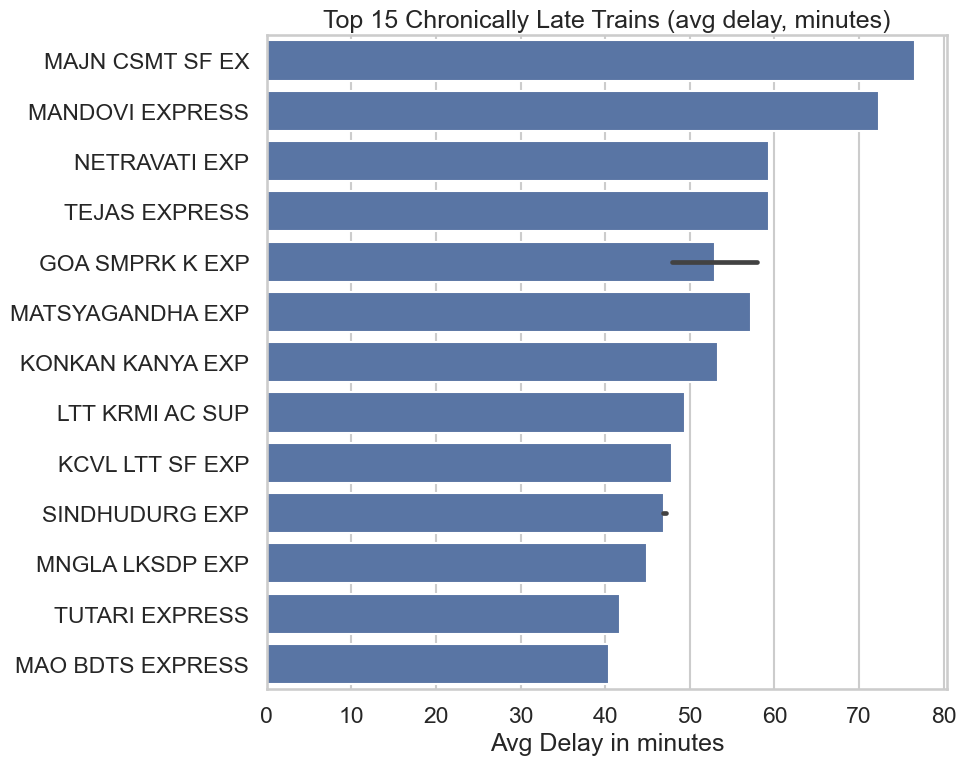

In [36]:
top15_trains = train_delay.head(15)
plt.figure(figsize=(10, 8))
sns.barplot(data=top15_trains, y="train_name", x="avg_delay")
plt.title("Top 15 Chronically Late Trains (avg delay, minutes)")
plt.xlabel("Avg Delay in minutes")
plt.ylabel("")
plt.tight_layout()
plt.savefig("figures/top_trains_delay.png")
plt.show()

In [31]:
train_delay_high = train_delay[train_delay["coverage_tier"] == "High"].sort_values("avg_delay", ascending=False)
print(train_delay_high.head(10))

    train_no        train_name   type_code coverage_tier  n_records  \
0      12134   MAJN CSMT SF EX   SF-TRAINS          High       5312   
1      10103   MANDOVI EXPRESS  EXP-TRAINS          High       7297   
2      16345     NETRAVATI EXP  EXP-TRAINS          High      17692   
5      12619  MATSYAGANDHA EXP   SF-TRAINS          High       8395   
6      20111  KONKAN KANYA EXP   SF-TRAINS          High       6932   
10     10105    SINDHUDURG EXP  EXP-TRAINS          High      12589   
11     10106    SINDHUDURG EXP  EXP-TRAINS          High      12589   
12     12618   MNGLA LKSDP EXP   SF-TRAINS          High      15695   
13     11004    TUTARI EXPRESS  EXP-TRAINS          High       7454   
15     12620   MATSYAGANDA EXP   SF-TRAINS          High       7665   

    avg_delay  std_delay  
0    76.55629  83.319778  
1    72.30437  75.614366  
2    59.37802  58.079067  
5    57.27564  65.445879  
6    53.36887  44.233923  
10   47.14314  37.077187  
11   46.82461  34.128998  
12

In [32]:
station_query = """
SELECT
    s.station_code, s.station_full_name, s.station_zone,
    COUNT(*) AS n_records,
    AVG(delay_minutes) AS avg_delay
FROM delays d
JOIN stations s ON d.station_code = s.station_code
GROUP BY s.station_code, s.station_full_name, s.station_zone
ORDER BY avg_delay DESC;
"""
station_delay = pd.read_sql(text(station_query), engine)
print(station_delay.head(15))

   station_code station_full_name station_zone  n_records  avg_delay
0           NIV           NIVASAR           KR        730   67.07808
1           ANO            ANJANI           KR        390   66.70000
2           PNP        PANIPAT JN           NR        209   64.21531
3          VRLI          VERAVALI           KR        730   61.32603
4           KKW         KANKAVALI           KR       5287   60.78608
5          KRMI           KARMALI           KR       3942   60.74353
6          THVM            THIVIM           KR       4061   59.15169
7          ADVI           ADAVALI           KR       2190   57.89772
8          RAJP      RAJAPUR ROAD           KR       3274   57.52046
9          PERN            PERNEM           KR       1773   57.42809
10         KUDL             KUDAL           KR       4985   57.42287
11         SRTL         SHERTALAI           SR        729   56.16187
12         SNDD        SINDHUDURG           KR       3232   56.01021
13          VBW    VAIBHAVWADI RD 

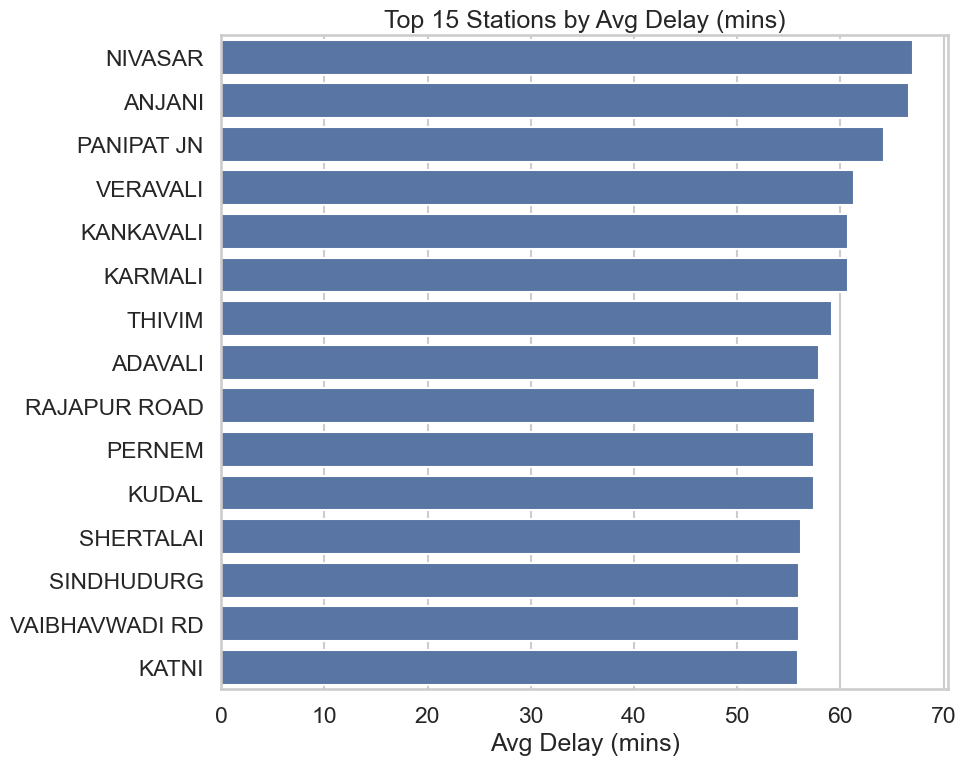

In [35]:
top15_stations = station_delay.head(15)
plt.figure(figsize=(10, 8))
sns.barplot(data=top15_stations, y="station_full_name", x="avg_delay")
plt.title("Top 15 Stations by Avg Delay (mins)")
plt.xlabel("Avg Delay (mins)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("figures/top_stations_delay.png")
plt.show()